# Running the Virtual Ecosystem in Static Mode

## Why use Static Mode?

Imagine standing in a rainforest clearing at dawn. The sun rises, mist lifts, and the
forest slowly comes to life.

Now imagine you could pause parts of this scene — hold
the soil moisture constant, freeze the behaviour of animals, or keep the microclimate
unchanged — while the rest of the ecosystem continues to move through time.

This is the essence of the Static Mode in the Virtual Ecosystem model.

In complex systems where everything interacts it can be hard to isolate what’s
causing what. Static Mode helps untangle this web by letting you "freeze" components
like plants or animals while others remain dynamic. At each model step, static
components reset to their original state (e.g. eaten leaves magically reappear) —
like a controlled reset — so any change comes only from the active, evolving parts.

This setup enables **targeted experiments** within the full model framework. For
example, you can test how vegetation responds to changing temperatures without feedback
from soil moisture changes, or explore animal behaviour in a fixed vegetation landscape.

By choosing which components evolve over time and which stay fixed, Static Mode helps
reveal drivers of ecological change - helping us understand not just
what happens, but why.

```{note}
The Virtual Ecosystem model can, in theory, be run with any combination of one or more
components held static (except `core`). However, not all combinations are equally
meaningful. It's worth
considering your experimental goals carefully and selecting static–dynamic
configurations that best support the processes you want to isolate or understand.
```

## Using the static mode

This example demonstrates how to configure and run the Virtual Ecosystem with selected
components held static (for more technical details,
[see](./core_settings/static_models.md)). Specifically, we focus on **hydrology**
by keeping the
microclimate, vegetation, animals, litter, and soils fixed. This isolates hydrological
processes and so we can examine how individual model parameters and process
representations influence model behaviour.

We run two experiments:

- HydroDefault: 'hydrology-only' simulation with default configuration
- HydroDry: 'hydrology-only' simulation with reduced initial soil moisture

In practice this means:

- Microclimate is fixed: e.g., temperature and relative humidity stay constant
- Plants are static: e.g. water uptake, transpiration, and interception do not vary
- Soil microbes, litter, and animals do not feedback into hydrology
- Only hydrology processes evolve over time in response to precipitation

Finally, we compare their outputs to the default setup (`ve_example`) where all
components run dynamically.

```{note}
This guide focuses on how to technically configure and run static mode, not on
interpreting the experimental results. This enables you to adapt the setup to suit your
own analysis goals.

The code below to run the Virtual Ecosystem and plot results uses a mixture of the
command line (e.g. `bash` on Linux or MacOS, `powershell` on Windows) and python code.
For the code run at the command line, we currently only show the syntax for using
`bash`. On Windows, you will need to change the paths (for example, to
`C:\Users\username\Temp\...`).
```

### 1: Run `ve_example` as a baseline

Before setting up static experiments, make sure you can run the model successfully.
If you haven’t yet installed and executed the example, follow the
[example instructions](./virtual_ecosystem_in_use) to familiarise yourself with the
setup.

In [1]:
%%bash
# Remove any existing VE data directory in the /tmp/ directory
if [ -d /tmp/ve_example ]; then
  rm -r /tmp/ve_example
fi

Install the example code - do make sure that you don't have an old copy of this example
code in your temporary directory before starting this exercise!

In [2]:
%%bash
# Install the example data directory from the Virtual Ecosystem package
ve_run --install-example /tmp/

Example directory created at:
/tmp/ve_example


Run the example model with the provided full configuration. Note that all of the model runs in this notebook use the `--to-netcdf` argument to postprocess the outputs back into a NetCDF file using XY coordinates.

In [3]:
%%script bash --err discarded_stderr
# Run the example
ve_run /tmp/ve_example/config/data_config.toml \
  /tmp/ve_example/config/abiotic_simple_config.toml \
  /tmp/ve_example/config/animal_config.toml \
  /tmp/ve_example/config/hydrology_config.toml \
  /tmp/ve_example/config/litter_config.toml \
  /tmp/ve_example/config/plant_config.toml \
  /tmp/ve_example/config/soil_config.toml \
  --outpath /tmp/ve_example/out/ \
  --logfile /tmp/ve_example/out/ve_example.log \
  --to-netcdf

* Starting Virtual Ecosystem simulation using v0.2.1.
* Logging to: /tmp/ve_example/out/ve_example.log
* Loading configuration
* Configuration validated
* Saved compiled configuration: /tmp/ve_example/out/compiled_configuration.toml
* Built core model components
* Initial data loaded
* Models initialised: abiotic_simple, animal, hydrology, litter, plants, soil
* Initialisation data export complete.
* Starting simulation
100%|██████████| 24/24 [00:56<00:00,  2.37s/it]
* Simulation completed
* Data postprocessed to NetCDF.
Virtual Ecosystem run complete.


### 2: HydroDefault experiment

#### Configure static components

Once the baseline run is complete, you can set up an experiment that runs
the hydrology model under otherwise static conditions. This does not change
the parameterisation or input data, just holds the other models static.

- **Create a new output directory** `HydroDefault_out` for the simulation in the `ve_example` directory.
- You need to setup a new configuration file that runs the model with most
  models in static. Conveniently, you can use the compiled configuration
  from the last experiment, so copy `out/compiled_configuration.toml` to
  `config/HydroDefault_config.toml`.
- In the new file, set `static = true` for all components
  **except hydrology and core**, e.g.:

  ```toml
  [abiotic_simple]
  static=true
  ```
- Save the updated configuration.

In [4]:
# Generate the static config file programmatically
import tomllib

import tomli_w

# Load the original config
with open("/tmp/ve_example/out/compiled_configuration.toml", "rb") as cfg:
    config = tomllib.load(cfg)

# Update the static settings
config["abiotic_simple"]["static"] = True
config["plants"]["static"] = True
config["animal"]["static"] = True
config["soil"]["static"] = True
config["litter"]["static"] = True

# Save to a new file
with open("/tmp/ve_example/config/HydroDefault_config.toml", "wb") as out:
    tomli_w.dump(config, out)

#### Run HydroDefault experiment

Now run the model with the new configuration from your command line:

- The command only needs to point to a single configuration file, since
  you are using the compiled configuration.
- The `--outpath` and `--logfile` arguments need to point to the new
  output directory.

In [5]:
%%script bash 
mkdir -p /tmp/ve_example/HydroDefault_out

ve_run /tmp/ve_example/config/HydroDefault_config.toml \
  --out /tmp/ve_example/HydroDefault_out \
  --logfile /tmp/ve_example/HydroDefault_out/HydroDefault.log \
  --to-netcdf

* Starting Virtual Ecosystem simulation using v0.2.1.
* Logging to: /tmp/ve_example/HydroDefault_out/HydroDefault.log
* Loading configuration
* Configuration validated
* Saved compiled configuration: /tmp/ve_example/HydroDefault_out/compiled_configuration.toml
* Built core model components
* Initial data loaded
* Models initialised: abiotic_simple, animal, hydrology, litter, plants, soil
* Initialisation data export complete.
* Starting simulation
100%|██████████| 24/24 [00:19<00:00,  1.22it/s]
* Simulation completed
* Data postprocessed to NetCDF.
Virtual Ecosystem run complete.


#### Compare HydroConst results to baseline

To compare the results of the HydroDefault experiment to the fully dynamic `ve_example`,
load the continuous results from `/ve_example/out/` and `/ve_example/HydroDefault_out/`:

In [6]:
import matplotlib.pyplot as plt
import xarray

# Example: load or define your datasets
ve_example = xarray.load_dataset("/tmp/ve_example/out/model_data.nc", group="outputs")
hydrodefault = xarray.load_dataset(
    "/tmp/ve_example/HydroDefault_out/model_data.nc", group="outputs"
)

##### Air temperature above the canopy

The air temperature above the canopy is provided by an external data source at each
time step. In the *dynamic abiotic mode*, this input is a time series to the Virtual
Ecosystem that changes over time, allowing the model to respond to seasonal variation in
atmospheric conditions. In *static abiotic mode*, by contrast, the same temperature
value is used repeatedly for every time step throughout the simulation (think of
groundhog day, the movie).

This difference has important implications for the hydrology model behaviour. In dynamic
abiotic mode, fluctuations in air temperature can drive changes in evaporation, soil
moisture, and other hydrological processes, leading to more realistic diurnal and
seasonal cycles. In static abiotic mode, these processes may stabilize at an artificial
equilibrium that reflects the constant atmospheric forcing rather than natural
variability. This makes the static mode useful for isolating the role of internal model
dynamics, but less representative of real-world conditions.

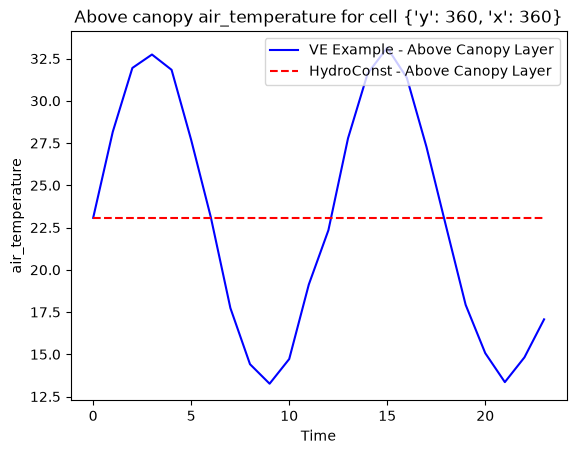

In [7]:
# Choose the variable name
var_name = "air_temperature"
# Set the and xy coords of a cell to plot and the layer
xy = {"y": 360, "x": 360}
coords = {**xy, "layer_roles": "above"}

# Plot the values for each of the two experiments
plt.plot(
    ve_example["time_index"],
    ve_example[var_name].sel(**coords),
    label="VE Example - Above Canopy Layer",
    linestyle="-",
    color="blue",
)
plt.plot(
    hydrodefault["time_index"],
    hydrodefault[var_name].sel(**coords),
    label="HydroConst - Above Canopy Layer",
    linestyle="--",
    color="red",
)

plt.xlabel("Time")
plt.ylabel(var_name)
plt.title(f"Above canopy {var_name} for cell {xy}")
plt.legend()
plt.show()

##### Soil moisture

The next figure shows the evolution of soil moisture over time for the same cell.

* The topsoil moisture shows distinctly different patterns between the two scenario.
* The subsoil moisture appears identical for the two scenarios. This
  suggests that, under the conditions tested, subsoil moisture dynamics may be relatively
  insensitive to fluctuations in abiotic conditions — or that other model components
  dominate the response. However, understanding why this occurs would require a deeper
  investigation into the model's energy and water balance under both configurations.

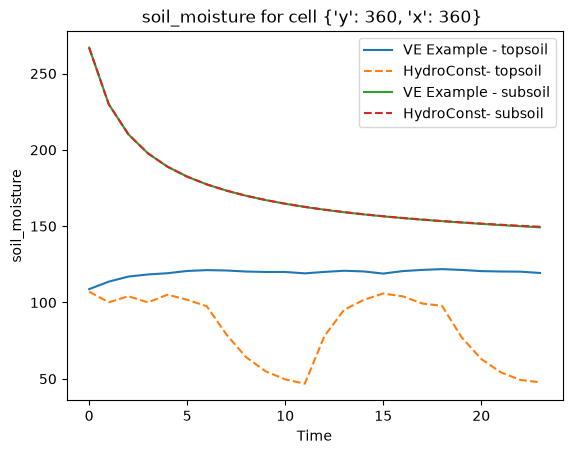

In [8]:
# Choose the variable and  xy coordinates of the cell to plot
var_name = "soil_moisture"

# Set the vertical layers to the plot
soil_layers = ["topsoil", "subsoil"]
n_layers = len(soil_layers)

# Plot soil moisture for each layer
for i, layer_role in enumerate(soil_layers):
    plt.plot(
        ve_example["time_index"],
        ve_example[var_name].sel(**xy, layer_roles=layer_role),
        label=f"VE Example - {layer_role}",
        linestyle="-",
    )
    plt.plot(
        hydrodefault["time_index"],
        hydrodefault[var_name].sel(**xy, layer_roles=layer_role),
        label=f"HydroConst- {layer_role}",
        linestyle="--",
    )

plt.xlabel("Time")
plt.ylabel(var_name)
plt.title(f"{var_name} for cell {xy} ")
plt.legend()
plt.show()

### 4: HydroDry experiment

#### Configure lower initial soil moisture

To set up a hydrology-only experiment with a change in initial soil moisture, follow
these steps:

- Again, **create a new output directory** `HydroDry_out` for the simulation in the `ve_example` directory.
- Copy the static configuration you created `config/HydroDefault_config.toml` to `config/HydroDry_config.toml`
- Edit the new configuration to change the
  initial soil moisture from the default value of 0.5 to 0.3.

```{code-block} toml
:emphasize-lines: 2

[hydrology]
initial_soil_moisture = 0.3
initial_groundwater_saturation = 0.9
static = false
```

In [9]:
# Load the original config
with open("/tmp/ve_example/config/HydroDefault_config.toml", "rb") as cfg:
    config = tomllib.load(cfg)

# Modify initial soil moisture
config["hydrology"]["initial_soil_moisture"] = 0.3

# Save to a new file
with open("/tmp/ve_example/config/HydroDry_config.toml", "wb") as out:
    tomli_w.dump(config, out)

#### Run HydroDry experiment

Now run the model with the new configuration from your command line. Again, make sure
that the `--outpath` command in the second line is followed by the directory of the new
output folder that you just created (here `/tmp/ve_example/HydroDry_out/`),
and the `--logfile` command in the third line is followed by the same path and a new
file name ending in `.log`:

In [10]:
%%script bash --err discarded_stderr
mkdir -p /tmp/ve_example/HydroDry_out

ve_run /tmp/ve_example/config/HydroDry_config.toml \
  --outpath /tmp/ve_example/HydroDry_out/ \
  --logfile /tmp/ve_example/HydroDry_out/HydroDry.log \
  --to-netcdf

* Starting Virtual Ecosystem simulation using v0.2.1.
* Logging to: /tmp/ve_example/HydroDry_out/HydroDry.log
* Loading configuration
* Configuration validated
* Saved compiled configuration: /tmp/ve_example/HydroDry_out/compiled_configuration.toml
* Built core model components
* Initial data loaded
* Models initialised: abiotic_simple, animal, hydrology, litter, plants, soil
* Initialisation data export complete.
* Starting simulation
100%|██████████| 24/24 [00:19<00:00,  1.25it/s]
* Simulation completed
* Data postprocessed to NetCDF.
Virtual Ecosystem run complete.


#### Compare HydroConst and HydroDry results

To compare the results of different initial soil moisture levels in the hydrology-only
configuration, load the continuous results from `/ve_example/HydroDry_out/`:

In [11]:
hydrodry = xarray.load_dataset(
    "/tmp/ve_example/HydroDry_out/model_data.nc", group="outputs"
)

##### Soil moisture initial conditions

Now repeat the plotting of soil moisture over time for both experiments.
You can see that the effects are subtle. Unsurprisingly, the two soil layers start with lower soil moisture in the dry experiment but they converge on similar values by the end of the experiment, and the two layers show similar temporal patterns in the two treatments.

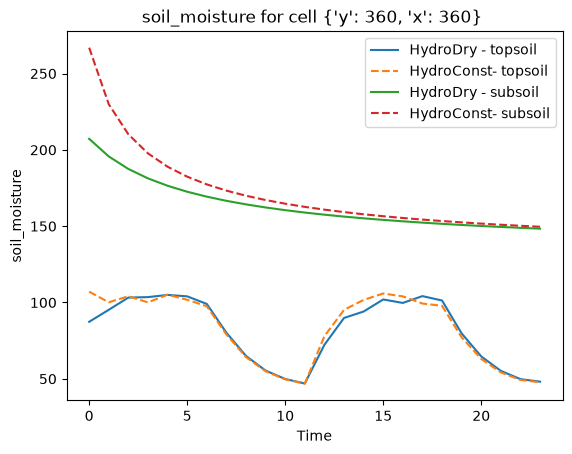

In [12]:
# Choose the variable and  xy coordinates of the cell to plot
var_name = "soil_moisture"

# Set the vertical layers to the plot
soil_layers = ["topsoil", "subsoil"]
n_layers = len(soil_layers)

# Plot soil moisture for each layer
for i, layer_role in enumerate(soil_layers):
    plt.plot(
        hydrodry["time_index"],
        hydrodry[var_name].sel(**xy, layer_roles=layer_role),
        label=f"HydroDry - {layer_role}",
        linestyle="-",
    )
    plt.plot(
        hydrodefault["time_index"],
        hydrodefault[var_name].sel(**xy, layer_roles=layer_role),
        label=f"HydroConst- {layer_role}",
        linestyle="--",
    )

plt.xlabel("Time")
plt.ylabel(var_name)
plt.title(f"{var_name} for cell {xy} ")
plt.legend()
plt.show()

## Timeseries inputs for static models

As we have mentioned, Static Mode let you freeze a model in time, and let the others run using a snapshot of it. You might want, however, to keep some of the variables originally updated by the static models evolving with time. As the models are static, they cannot change, so the way of doing this in Virtual Ecosystem is by _providing those timeseries variables as inputs_.

This is an exception to the default model validation process by which, if a model is static, the variables it handles can be provided as inputs and have a `time_index` dimension, something that is not allowed when the model is dynamic - the whole point of the model is to update those variables as time goes by! The possibility - not obligation - of providing input data as a time series applies to all of the variables a static model handles, and not only the forcing variables (e.g. climate data), which is normally the case.

Finally, keep in mind that you can either provide **all** the variables a model would otherwise handle or **none**. Providing just a few is not allowed. The reason for this restriction is that if only a handful are provided, there might be internal inconsistencies in the model, with some variables being calculated during setup or first update (before the freeze) that are not in agreement with the provided inputs. To avoid these inconsistencies - or at least to leave them in the hands of the user - when it comes to overriding static models variables, is a question of all or nothing.

Read the [section on running VE for your location](./running_ve_with_your_own_data.md) for more information on how to provide custom variables to VE.

